# 04_robustness — Robustness Analysis and Metric Refinement

## Obiettivi

Dopo aver costruito le metriche longitudinali di diversità dei generi e di diversità geografica, questo notebook ha due obiettivi principali:
1. Valutare la robustezza dei risultati ottenuti rispetto a differenti misure di diversità.
2. Costruire una versione più granulare della metrica di Novelty, al fine di verificare se il declino osservato nella novelty basata 
   sui 19 macro-generi rappresenti un reale restringimento delle preferenze oppure un artefatto dovuto all'effetto soffitto della tassonomia utilizzata.

In particolare verranno sviluppate le seguenti analisi:
- confronto tra Shannon Entropy e Simpson Diversity
- costruzione di una nuova metrica di Novelty basata sui Genome Tags di MovieLens
- confronto tra Novelty classica e Novelty raffinata
- individuazione di eventuali punti di cambiamento (change-point) nella traiettoria temporale della diversità
- verifica della robustezza dei risultati rispetto alle differenti metriche

### Import delle librerie

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

print("Ambiente configurato correttamente")

Ambiente configurato correttamente


### Definizione dei percorsi

In [2]:
project_root = Path.cwd().parent

data_path = project_root / "data"
processed_path = data_path / "processed"

print("Project root:", project_root)
print("Processed path:", processed_path)

Project root: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens
Processed path: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/data/processed


### Caricamento dei dataset

In [3]:
ratings_path = data_path / "raw" / "ml-25m" / "ratings.csv"
movies_path = data_path / "raw" / "ml-25m" / "movies.csv"

genome_scores_path = data_path / "raw" / "ml-25m" / "genome-scores.csv"
genome_tags_path = data_path / "raw" / "ml-25m" / "genome-tags.csv"

user_year_path = ( processed_path / "user_year_genre_longitudinal.parquet")

geo_path = ( processed_path / "user_year_geo_longitudinal.parquet")

ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

genome_scores = pd.read_csv(genome_scores_path)
genome_tags = pd.read_csv(genome_tags_path)

user_year = pd.read_parquet(user_year_path)
geo = pd.read_parquet(geo_path)

In [4]:
# copia di genome_scores, salvata subito dopo il caricamento e PRIMA di qualsiasi filtro
# serve più avanti per la sensitivity analysis (soglia 0.7 / top-k)
genome_scores_orig = genome_scores.copy()

#### Controllo dei dataset

In [5]:
print("ratings:", ratings.shape)
print("movies:", movies.shape)

print("genome_scores:", genome_scores.shape)
print("genome_tags:", genome_tags.shape)

print("user_year:", user_year.shape)
print("geo:", geo.shape)

ratings: (25000095, 4)
movies: (62423, 3)
genome_scores: (15584448, 3)
genome_tags: (1128, 2)
user_year: (101722, 26)
geo: (240347, 4)


In [6]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
genome_scores.head()

,movieId,tagId,relevance
0,1,1,0.02875
1,1,2,0.02375
2,1,3,0.06250
3,1,4,0.07575
4,1,5,0.14075


In [9]:
genome_tags.head()

,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century
3,4,1920s
4,5,1930s


### Esplorazione dei Genome Tags
La Novelty basata sui 19 macro-generi presenta un evidente effetto soffitto: la maggior parte degli utenti esplora rapidamente quasi tutti i generi disponibili, rendendo difficile distinguere una reale riduzione dell'esplorazione da una saturazione della tassonomia.

Per superare questo limite viene introdotta una metrica alternativa basata sui MovieLens Genome Tags.

I Genome Tags rappresentano descrizioni semantiche più granulari dei film e consentono di analizzare l'evoluzione delle preferenze degli utenti a un livello più dettagliato rispetto ai generi principali.

#### Controllo dimensioni

In [10]:
print("Numero tag disponibili:", genome_tags["tagId"].nunique())

print("Numero film con Genome scores:", genome_scores["movieId"].nunique())

print("Numero osservazioni Genome:", len(genome_scores))

Numero tag disponibili: 1128


Numero film con Genome scores: 13816
Numero osservazioni Genome: 15584448


#### Distribuzione dei relevance (quanto un tag è associato al film)

In [11]:
genome_scores["relevance"].describe()

count    1.558445e+07
mean     1.163679e-01
std      1.544722e-01
min      2.500000e-04
25%      2.400000e-02
50%      5.650000e-02
75%      1.407500e-01
max      1.000000e+00
Name: relevance, dtype: float64

##### Visualizzazione

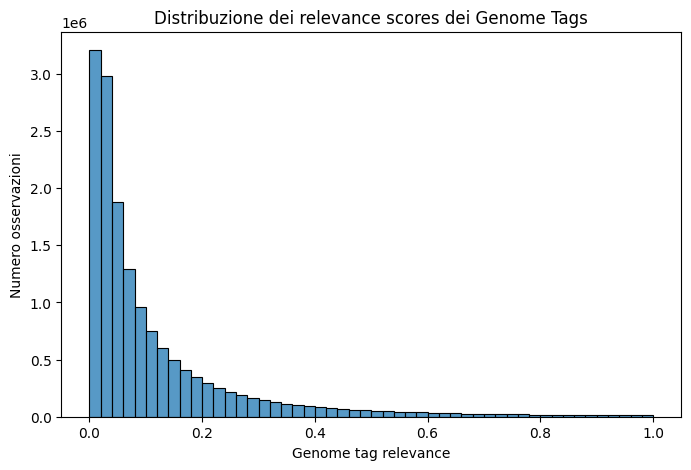

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    genome_scores["relevance"],
    bins=50
)

plt.xlabel("Genome tag relevance")
plt.ylabel("Numero osservazioni")

plt.title(
    "Distribuzione dei relevance scores dei Genome Tags"
)

plt.show()

#### Numero medio di tag per film
Vedimo quanti tag rimangono usando una soglia provvisoria

In [13]:
TAG_THRESHOLD = 0.5

# applichiamo il filtro
genome_scores_filtered = genome_scores[
    genome_scores["relevance"] >= TAG_THRESHOLD
].copy()

# calcoliamo quanti tag per film
tags_per_movie = (
    genome_scores_filtered
    .groupby("movieId")
    .size()
)
tags_per_movie.describe()


count    13816.00000
mean        44.52432
std         27.96506
min          1.00000
25%         25.00000
50%         37.00000
75%         57.00000
max        305.00000
dtype: float64

##### Visualizzazione

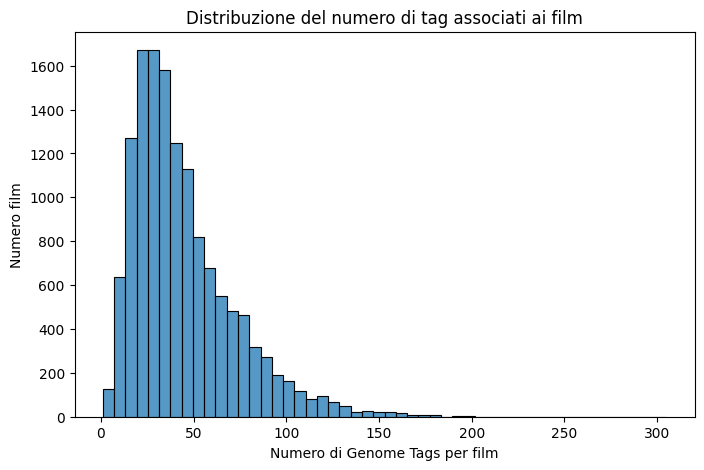

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    tags_per_movie,
    bins=50
)

plt.xlabel(
    "Numero di Genome Tags per film"
)

plt.ylabel(
    "Numero film"
)

plt.title(
    "Distribuzione del numero di tag associati ai film"
)

plt.show()

#### Scelta della soglia
Confronto diverse soglie

In [15]:
thresholds = [0.3,0.5,0.7]

for threshold in thresholds:
    
    tmp = genome_scores[
        genome_scores["relevance"] >= threshold
    ]
    
    avg_tags = (
        tmp
        .groupby("movieId")
        .size()
        .mean()
    )
    
    print(
        f"Soglia {threshold}: "
        f"{avg_tags:.2f} tag medi per film"
    )

Soglia 0.3: 112.00 tag medi per film
Soglia 0.5: 44.52 tag medi per film
Soglia 0.7: 17.75 tag medi per film


L'analisi mostra che il numero medio di tag associati ai film varia sensibilmente in funzione della soglia di relevance.
Una soglia pari a **0.5** rappresenta un buon compromesso tra completezza e selettività: elimina le associazioni deboli mantenendo comunque una rappresentazione semantica sufficientemente ricca di ciascun film.
Per le analisi successive verrà quindi adottata una soglia di relevance pari a **0.5**.

#### Controllo quanti film del dataset dei rating possiedono Genome Tags

In [16]:
movies_with_genome = genome_scores["movieId"].nunique()

movies_total = ratings["movieId"].nunique()

print(f"Film nel dataset: {movies_total}")

print(f"Film con Genome Tags: {movies_with_genome}")

print(
    f"Copertura: {movies_with_genome/movies_total:.2%}"
)

Film nel dataset: 59047
Film con Genome Tags: 13816
Copertura: 23.40%


### Costruzione della Novelty basata sui Genome Tags
Per superare il limite della tassonomia composta da soli 19 macro-generi, viene costruita una nuova misura di Novelty basata sui Genome Tags di MovieLens.
La logica rimane identica alla metrica precedente:
- un tag viene considerato "nuovo" se compare per la prima volta nella storia dell'utente
- la Novelty annuale è definita come la quota di tag osservati per la prima volta rispetto al totale dei tag incontrati durante l'anno

In questo modo è possibile valutare se il calo della Novelty osservato con i generi dipenda realmente da una riduzione dell'esplorazione oppure dall'effetto soffitto della tassonomia originaria.

#### Costruzione del dataset film-tag

In [17]:
# costruisco la tabella con movieId, tagId, tag e relevance
genome = genome_scores.merge(
    genome_tags,
    on="tagId",
    how="left"
)
genome.head()

,movieId,tagId,relevance,tag
0,1,1,0.02875,007
1,1,2,0.02375,007 (series)
2,1,3,0.06250,18th century
3,1,4,0.07575,1920s
4,1,5,0.14075,1930s


In [18]:
# applico la soglia
genome = genome[
    genome["relevance"] >= TAG_THRESHOLD
].copy()

In [19]:
# controllo
print("Film coperti:", genome["movieId"].nunique())

print("Tag distinti:", genome["tagId"].nunique())

print("Osservazioni:", len(genome))

Film coperti: 13816
Tag distinti: 1127
Osservazioni: 615148


#### Costruzione della rappresentazione semantica dei film

Per evitare la generazione di un dataset estremamente grande, i Genome Tags vengono organizzati in una struttura dizionario.
Ogni film viene associato all'insieme dei Genome Tags con relevance ≥ 0.5.
Questa rappresentazione compatta verrà utilizzata per aggiornare progressivamente la cronologia dei tag osservati da ciascun utente.

In [20]:
movie_tags = (
    genome
    .groupby("movieId")["tagId"]
    .apply(set)
    .to_dict()
)

In [21]:
# controllo
print("Film con Genome:", len(movie_tags))
first_movie = next(iter(movie_tags))
print("Primo film:", first_movie)
print("Numero tag:", len(movie_tags[first_movie]))

Film con Genome: 13816
Primo film: 1
Numero tag: 96


#### Preparazione dei rating
I rating vengono ordinati cronologicamente per ciascun utente.
Per ogni film viene successivamente recuperato l'insieme dei Genome Tags corrispondente.

In [22]:
ratings["year"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
).dt.year

In [23]:
ratings_small = ratings[
    [
        "userId",
        "movieId",
        "year"
    ]
].copy()

#### Copertura reale dei rating con Genome Tags (calcolata prima del filtro)
Calcolo la statistica di copertura sul totale dei rating originali, quindi prima di applicare il filtro per contenere solo i film con Genome Tags. 
Qui sotto viene calcolata sia a livello di rating (quota di rating che cadono su film con Genome Tags) sia a livello di film (quota di film distinti che hanno Genome Tags), come già mostrata in precedenza.

In [24]:
# copertura calcolata sui rating originali PRIMA di qualsiasi filtro sui Genome Tags
n_ratings_total = len(ratings)
ratings_with_genome_mask = ratings["movieId"].isin(movie_tags)
n_ratings_with_genome = int(ratings_with_genome_mask.sum())

coverage_ratings_correct = n_ratings_with_genome / n_ratings_total

print("Copertura a livello di RATING")
print(f"Rating totali nel dataset: {n_ratings_total:,}")
print(f"Rating su film con Genome Tags: {n_ratings_with_genome:,}")
print(f"Copertura reale (rating-level): {coverage_ratings_correct:.2%}")

print()
print("Copertura a livello di FILM (da cella precedente)")
print(f"Film con Genome Tags: {movies_with_genome:,} su {movies_total:,} "
      f"({movies_with_genome/movies_total:.2%})")

Copertura a livello di RATING
Rating totali nel dataset: 25,000,095
Rating su film con Genome Tags: 24,674,113
Copertura reale (rating-level): 98.70%

Copertura a livello di FILM (da cella precedente)
Film con Genome Tags: 13,816 su 59,047 (23.40%)


**Interpretazione**: la copertura a livello di film è bassa (23.4%: solo 13.816 film su 59.047 hanno
Genome Tags), mentre la copertura a livello di rating è nettamente più alta. 
Questo scarto conferma che i film con Genome Tags **non sono un campione casuale** dei film disponibili, ma sono
sistematicamente i più popolari/valutati. Di conseguenza, ogni metrica costruita sui Genome Tags tende a privilegiare i consumi di massa escludendo sistematicamente i film di nicchia, e questo è un limite della metrica.

#### Teniamo solo i film che possiedono Genome Tags

In [25]:
ratings_small = ratings_small[
    ratings_small["movieId"].isin(movie_tags)
].copy()

#### Ordinamento

In [26]:
ratings_small = ratings_small.sort_values(
    [
        "userId",
        "year"
    ]
)
ratings_small.head()

,userId,movieId,year
0,1,296,2006
1,1,306,2006
2,1,307,2006
3,1,665,2006
4,1,899,2006


In [27]:
ratings_small.shape

(24674113, 3)

#### Filtro solo i film presenti nei rating

In [28]:
movie_ids_used = ratings_small["movieId"].unique()

genome_scores = genome_scores[
    genome_scores["movieId"].isin(movie_ids_used)
].copy()

print(genome_scores.shape)

(15584448, 3)


#### Applicazione soglia di rilevanza

In [29]:
GENOME_THRESHOLD = 0.5

genome_scores_filtered = genome_scores[
    genome_scores["relevance"] >= GENOME_THRESHOLD
].copy()

genome_scores_filtered.shape

(615148, 3)

#### Creazione mapping film → tag

In [30]:
movie_tags = (
    genome_scores_filtered
    .groupby("movieId")["tagId"]
    .apply(set)
    .reset_index()
)

movie_tags.head()

,movieId,tagId
0,1,"{11, 1035, 1036, 529, 19, 535, 536, 29, 30, 10..."
1,2,"{132, 646, 777, 266, 19, 21, 662, 29, 414, 415..."
2,3,"{481, 451, 901, 230, 646, 264, 742, 777, 299, ..."
3,4,"{388, 1035, 913, 21, 28, 412, 545, 1062, 439, ..."
4,5,"{768, 387, 388, 900, 646, 901, 902, 1033, 650,..."


#### Merge con i rating

In [31]:
# collegamento tag ai film visti
ratings_tags = ratings_small.merge(
    movie_tags,
    on="movieId",
    how="inner"
)

ratings_tags.head()

,userId,movieId,year,tagId
0,1,296,2006,"{512, 1024, 519, 528, 529, 18, 19, 536, 1049, ..."
1,1,306,2006,"{1046, 536, 30, 1062, 1064, 557, 46, 569, 1090..."
2,1,307,2006,"{640, 641, 769, 771, 266, 779, 1037, 270, 143,..."
3,1,665,2006,"{128, 640, 265, 1037, 270, 18, 146, 402, 535, ..."
4,1,899,2006,"{514, 4, 5, 6, 388, 266, 140, 270, 277, 918, 5..."


#### Controllo copertura

In [32]:
coverage_tags = (
    len(ratings_tags) /
    len(ratings_small)
)

print(
    f"Copertura ratings_tags / ratings_small (sotto-campione già filtrato, atteso ~100%): {coverage_tags:.2%}"
)
print(
    f"Copertura reale sul totale dei rating originali: {coverage_ratings_correct:.2%}"
)

Copertura ratings_tags / ratings_small (sotto-campione già filtrato, atteso ~100%): 100.00%
Copertura reale sul totale dei rating originali: 98.70%


#### Conversione movie_tags in dizionario

In [33]:
movie_to_tags = dict(
    zip(
        movie_tags["movieId"],
        movie_tags["tagId"]
    )
)
len(movie_to_tags)

13816

#### Aggiungiamo i tag

In [34]:
ratings_small["tags"] = ratings_small["movieId"].map(
    movie_to_tags
)

ratings_small = ratings_small.dropna(
    subset=["tags"]
)

ratings_small.head()

,userId,movieId,year,tags
0,1,296,2006,"{512, 1024, 519, 528, 529, 18, 19, 536, 1049, ..."
1,1,306,2006,"{1046, 536, 30, 1062, 1064, 557, 46, 569, 1090..."
2,1,307,2006,"{640, 641, 769, 771, 266, 779, 1037, 270, 143,..."
3,1,665,2006,"{128, 640, 265, 1037, 270, 18, 146, 402, 535, ..."
4,1,899,2006,"{514, 4, 5, 6, 388, 266, 140, 270, 277, 918, 5..."


#### Calcolo dei tag consumati per utente-anno

In [35]:
user_year_tags = (
    ratings_small
    .groupby(
        ["userId","year"]
    )["tags"]
    .apply(
        lambda x: set().union(*x)
    )
    .reset_index()
)

user_year_tags.head()

,userId,year,tags
0,1,2006,"{3, 4, 5, 6, 7, 8, 9, 10, 13, 18, 19, 20, 21, ..."
1,2,2006,"{1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 17, 1..."
2,3,2015,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,3,2016,"{1, 2, 5, 8, 10, 12, 18, 19, 20, 21, 22, 23, 2..."
4,3,2017,"{3, 5, 8, 9, 11, 12, 13, 18, 19, 20, 21, 22, 2..."


#### Ordinamento temporalmente

In [36]:
user_year_tags = user_year_tags.sort_values(
    [
        "userId",
        "year"
    ]
)

### Costruzione novelty granulare
Per ogni utente-anno calcolo: tag visti nell'anno, tag già visti negli anni precedenti, percentuale di nuovi tag

#### Funzione 

In [37]:
def compute_tag_novelty(group):

    seen_tag = set()
    novelty = []

    for tags in group["tags"]:

        new_tags = tags - seen_tag

        if len(tags) > 0:
            novelty.append(
                len(new_tags) / len(tags)
            )
        else:
            novelty.append(0)

        seen_tag.update(tags)

    group["tag_novelty"] = novelty

    # Recupero userId dal nome del gruppo,perché include_groups=False lo esclude dal DataFrame
    group["userId"] = group.name

    return group

#### Applicazione funzione

In [38]:
user_year_tags = (
    user_year_tags
    .groupby("userId", group_keys=False)
    .apply(compute_tag_novelty, include_groups=False)
)
user_year_tags.head()

,year,tags,tag_novelty,userId
0,2006,"{3, 4, 5, 6, 7, 8, 9, 10, 13, 18, 19, 20, 21, ...",1.000000,1
1,2006,"{1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 17, 1...",1.000000,2
2,2015,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1.000000,3
3,2016,"{1, 2, 5, 8, 10, 12, 18, 19, 20, 21, 22, 23, 2...",0.004525,3
4,2017,"{3, 5, 8, 9, 11, 12, 13, 18, 19, 20, 21, 22, 2...",0.010403,3


#### Aggiunta numero di tag

In [39]:
user_year_tags["n_tags"] = (
    user_year_tags["tags"]
    .apply(len)
)

In [40]:
user_year_tags.head()

,year,tags,tag_novelty,userId,n_tags
0,2006,"{3, 4, 5, 6, 7, 8, 9, 10, 13, 18, 19, 20, 21, ...",1.000000,1,731
1,2006,"{1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 17, 1...",1.000000,2,929
2,2015,"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1.000000,3,1052
3,2016,"{1, 2, 5, 8, 10, 12, 18, 19, 20, 21, 22, 23, 2...",0.004525,3,663
4,2017,"{3, 5, 8, 9, 11, 12, 13, 18, 19, 20, 21, 22, 2...",0.010403,3,769


#### Salviamo il database

In [41]:
user_year_genome = user_year_tags[
    [
        "userId",
        "year",
        "tag_novelty",
        "n_tags"
    ]
].copy()
user_year_genome.head()

,userId,year,tag_novelty,n_tags
0,1,2006,1.000000,731
1,2,2006,1.000000,929
2,3,2015,1.000000,1052
3,3,2016,0.004525,663
4,3,2017,0.010403,769


### Salvataggio

In [42]:
output_path = (
    processed_path /
    "user_year_genome_longitudinal.parquet"
)


user_year_genome.to_parquet(
    output_path,
    index=False
)

print("Salvato in: ", output_path)

Salvato in:  /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/data/processed/user_year_genome_longitudinal.parquet


## Ricalcolo dei modelli FE di riferimento (Entropia, Novelty sui generi)

`model_entropy` e `model_novelty` erano stati stimati in `02_EDA.ipynb`, quindi replico esattamente la stessa procedura di `02_EDA`. 
`log_ratings` non è salvato nel parquet `user_year_genre_longitudinal.parquet`, quindi lo ricreo qui.

In [43]:
import statsmodels.formula.api as smf

genre_df = pd.read_parquet(processed_path / "user_year_genre_longitudinal.parquet")

# log_ratings non e' salvato nel parquet quindi lo ricreo come in 02_EDA
genre_df["log_ratings"] = np.log1p(genre_df["n_ratings_year"])

# demeaning per il modello sull'Entropia (su campione completo)
cols_entropy = ["entropy", "active_year", "log_ratings"]
for col in cols_entropy:
    genre_df[f"{col}_dm"] = genre_df[col] - genre_df.groupby("userId")[col].transform("mean")

model_entropy = smf.ols(
    "entropy_dm ~ active_year_dm + log_ratings_dm + C(year)",
    data=genre_df
).fit(cov_type="cluster", cov_kwds={"groups": genre_df["userId"]})

#  demeaning per il modello sulla Novelty (su sotto-campione active_year >= 2) 
sample_novelty = genre_df[genre_df["active_year"] >= 2].copy()
cols_novelty = ["novelty_pct", "active_year", "log_ratings"]
for col in cols_novelty:
    sample_novelty[f"{col}_dm"] = sample_novelty[col] - sample_novelty.groupby("userId")[col].transform("mean")

model_novelty = smf.ols(
    "novelty_pct_dm ~ active_year_dm + log_ratings_dm + C(year)",
    data=sample_novelty
).fit(cov_type="cluster", cov_kwds={"groups": sample_novelty["userId"]})

print("REGRESSIONE EFFETTI FISSI: ENTROPIA (H) — ricalcolata")
print(model_entropy.summary().tables[1])
print()
print("REGRESSIONE EFFETTI FISSI: NOVELTY (19 generi) — ricalcolata")
print(model_novelty.summary().tables[1])

REGRESSIONE EFFETTI FISSI: ENTROPIA (H) — ricalcolata
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.3851      0.002   -231.022      0.000      -0.388      -0.382
C(year)[T.1996]     0.4317      0.004     98.176      0.000       0.423       0.440
C(year)[T.1997]     0.3527      0.004     88.723      0.000       0.345       0.361
C(year)[T.1998]     0.3750      0.008     47.689      0.000       0.360       0.390
C(year)[T.1999]     0.3913      0.004     92.103      0.000       0.383       0.400
C(year)[T.2000]     0.3584      0.003    103.830      0.000       0.352       0.365
C(year)[T.2001]     0.3517      0.003    100.985      0.000       0.345       0.358
C(year)[T.2002]     0.3929      0.004    111.103      0.000       0.386       0.400
C(year)[T.2003]     0.3659      0.004    104.013      0.000       0.359       0.373
C(year)[T.2004]     0.

## Confronto Novelty classica vs Novelty granulare (Genome Tags)

Uno degli obiettivi era verificare se la novelty granulare sui Genome Tags attenuasse l'effetto soffitto osservato con i 19 macro-generi. Per rispondere, il dataset `user_year_genome_longitudinal` lo unisco a `user_year_genre_longitudinal` (che fornisce `active_year`, `log_ratings` e l'anno di calendario) e stimo la stessa regressione a effetti fissi (demeaning per utente + errori standard clustered per utente + controllo per anno di calendario) già usata in `02_EDA` per
`novelty_pct`.

In [44]:
genome_compare = user_year_genome.merge(
    genre_df[["userId", "year", "active_year", "log_ratings"]],
    on=["userId", "year"],
    how="inner"
)

# stesso sotto-campione usato per la novelty classica (active_year >= 2)
genome_compare = genome_compare[genome_compare["active_year"] >= 2].copy()

print("Osservazioni disponibili per il confronto:", len(genome_compare))
genome_compare.head()

Osservazioni disponibili per il confronto: 72821


,userId,year,tag_novelty,n_tags,active_year,log_ratings
1,3,2016,0.004525,663,2,4.499810
2,3,2017,0.010403,769,3,5.398163
3,3,2019,0.013714,875,4,6.126869
5,5,1997,0.231332,683,2,4.905275
7,12,2000,0.044304,632,2,4.624973


In [45]:
# demeaning (effetti fissi utente) per la novelty granulare
cols_to_dm = ["tag_novelty", "active_year", "log_ratings"]
for col in cols_to_dm:
    genome_compare[f"{col}_dm"] = (
        genome_compare[col] - genome_compare.groupby("userId")[col].transform("mean")
    )

model_tag_novelty = smf.ols(
    "tag_novelty_dm ~ active_year_dm + log_ratings_dm + C(year)",
    data=genome_compare
).fit(cov_type="cluster", cov_kwds={"groups": genome_compare["userId"]})

print("REGRESSIONE EFFETTI FISSI: NOVELTY GRANULARE (Genome Tags)")
print(model_tag_novelty.summary().tables[1])

REGRESSIONE EFFETTI FISSI: NOVELTY GRANULARE (Genome Tags)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -5.928e-05   3.93e-05     -1.509      0.131      -0.000    1.77e-05
C(year)[T.1998]     0.0415      0.006      7.149      0.000       0.030       0.053
C(year)[T.1999]     0.0106      0.004      2.668      0.008       0.003       0.018
C(year)[T.2000]     0.0181      0.001     13.060      0.000       0.015       0.021
C(year)[T.2001]     0.0071      0.001      6.734      0.000       0.005       0.009
C(year)[T.2002]    -0.0033      0.001     -3.673      0.000      -0.005      -0.002
C(year)[T.2003]    -0.0040      0.001     -4.037      0.000      -0.006      -0.002
C(year)[T.2004]    -0.0059      0.001     -6.549      0.000      -0.008      -0.004
C(year)[T.2005]    -0.0094      0.001    -11.186      0.000      -0.011      -0.008
C(year)[T.2006]  

In [46]:
# confronto diretto dei coefficienti su active_year tra le due metriche di novelty
coef_novelty_genre = model_novelty.params["active_year_dm"]
pval_novelty_genre = model_novelty.pvalues["active_year_dm"]

coef_novelty_genome = model_tag_novelty.params["active_year_dm"]
pval_novelty_genome = model_tag_novelty.pvalues["active_year_dm"]

comparison_novelty = pd.DataFrame({
    "metrica": ["Novelty (19 generi)", "Novelty (Genome Tags)"],
    "coef_active_year": [coef_novelty_genre, coef_novelty_genome],
    "p_value": [pval_novelty_genre, pval_novelty_genome]
})
comparison_novelty

,metrica,coef_active_year,p_value
0,Novelty (19 generi),-0.002205,4.197310e-98
1,Novelty (Genome Tags),-0.004551,1.080792e-196


In [47]:
# quanti tag su quanti disponibili vengono toccati in media da un utente in un anno?
n_tags_available = genome_tags["tagId"].nunique()
avg_tags_per_user_year = user_year_genome["n_tags"].mean()

print(f"Tag disponibili nel vocabolario Genome: {n_tags_available}")
print(f"Tag distinti toccati in media da un utente in un anno: {avg_tags_per_user_year:.1f}")
print(f"Quota media del vocabolario coperta in un anno: {avg_tags_per_user_year/n_tags_available:.1%}")

avg_tags_per_movie = tags_per_movie.mean()
print(f"\nTag medi per film (soglia {TAG_THRESHOLD}): {avg_tags_per_movie:.1f}")

Tag disponibili nel vocabolario Genome: 1128
Tag distinti toccati in media da un utente in un anno: 690.6
Quota media del vocabolario coperta in un anno: 61.2%

Tag medi per film (soglia 0.5): 44.5


**Risultato contro-intuitivo**
Il passaggio dai 19 macro-generi ai ~1128 Genome Tags **non attenua** l'effetto soffitto, lo **aggrava**: il coefficiente di `active_year` è circa il doppio in negativo per la novelty granulare rispetto a quella sui generi. <br>
Guardando i dati grezzi si capisce il motivo: ogni film ha in media decine di tag a soglia 0.5, per cui bastano poche decine di film visti in un anno perché l'unione dei tag copra già gran parte dei ~1128 tag totali (un utente medio ne tocca circa il 60%). Il vocabolario è quindi "largo" (molte descrizioni semantiche per ogni film), non "profondo", e questo
lo rende **ancora più soggetto a saturazione rapida** dei 19 generi, non meno.

Quindi l'ipotesi di partenza (che una tassonomia più granulare avrebbe rivelato una vera riduzione
dell'esplorazione mascherata dall'effetto soffitto dei generi) **non è confermata dai dati**. <br>
Il risultato resta interessante perché mostra che l'effetto soffitto in questo dataset non è un artefatto della grana della
tassonomia usata, ma sembra riflettere un pattern più strutturale nel modo in cui gli utenti esauriscono rapidamente lo spazio delle categorie disponibili, qualunque sia la loro numerosità. <br>
Va inoltre ricordato il limite di copertura discusso sopra: la metrica sui Genome Tags è calcolata solo sul sottoinsieme di film mainstream con Genome Tags, quindi il confronto va letto con questa cautela.

## Sensitivity: soglia di relevance più selettiva (0.7) e top-k tag per film

Verifico se il pattern di saturazione osservato regge anche con un vocabolario più selettivo (soglia 0.7, ~18 tag/film) o con un top-k di tag per film, invece della soglia fissa a 0.5 (~44 tag/film).

In [48]:
def build_tag_novelty_dataset(genome_scores_raw, genome_tags_raw, ratings_raw, threshold=None, top_k=None):
    
    # ricostruisco il dataset di novelty granulare con una soglia di relevance 
    # oppure con un top-k di tag per film

    g = genome_scores_raw.merge(genome_tags_raw, on="tagId", how="left")

    if top_k is not None:
        g = (
            g.sort_values("relevance", ascending=False)
             .groupby("movieId", group_keys=False)
             .head(top_k)
        )
    else:
        g = g[g["relevance"] >= threshold].copy()

    movie_tags_local = g.groupby("movieId")["tagId"].apply(set).to_dict()

    r = ratings_raw[["userId", "movieId", "year"]].copy()
    r = r[r["movieId"].isin(movie_tags_local)].copy()
    r["tags"] = r["movieId"].map(movie_tags_local)
    r = r.sort_values(["userId", "year"])

    uy = (
        r.groupby(["userId", "year"])["tags"]
         .apply(lambda x: set().union(*x))
         .reset_index()
         .sort_values(["userId", "year"])
    )
    uy = uy.groupby("userId", group_keys=False).apply(compute_tag_novelty, include_groups=False).reset_index(drop=True)
    uy["n_tags"] = uy["tags"].apply(len)
    return uy[["userId", "year", "tag_novelty", "n_tags"]]


# soglia piu' selettiva: 0.7 (~18 tag/film)
user_year_genome_07 = build_tag_novelty_dataset(
    genome_scores_orig, genome_tags, ratings, threshold=0.7
)

# alternativa: top-10 tag per film, indipendentemente dalla soglia
user_year_genome_top10 = build_tag_novelty_dataset(
    genome_scores_orig, genome_tags, ratings, top_k=10
)

print("Soglia 0.7:", user_year_genome_07.shape)
print("Top-10:", user_year_genome_top10.shape)

Soglia 0.7: (240302, 4)
Top-10: (240303, 4)


La funzione sopra usa `genome_scores_orig`, la copia di `genome_scores` salvata subito
dopo il caricamento iniziale. Verifico che sia disponibile.

In [49]:
# controllo di sicurezza (genome_scores_orig deve essere già stato definito subito dopo il caricamento iniziale)
try:
    genome_scores_orig
    print("genome_scores_orig OK:", genome_scores_orig.shape)
except NameError:
    print("ATTENZIONE: genome_scores_orig non definito, lo ricarico da disco")
    genome_scores_orig = pd.read_csv(genome_scores_path)

genome_scores_orig OK: (15584448, 3)


In [50]:
def fit_novelty_fe_model(uy, genre_df):
    df_c = uy.merge(
        genre_df[["userId", "year", "active_year", "log_ratings"]],
        on=["userId", "year"], how="inner"
    )
    df_c = df_c[df_c["active_year"] >= 2].copy()

    for col in ["tag_novelty", "active_year", "log_ratings"]:
        df_c[f"{col}_dm"] = df_c[col] - df_c.groupby("userId")[col].transform("mean")

    m = smf.ols(
        "tag_novelty_dm ~ active_year_dm + log_ratings_dm + C(year)",
        data=df_c
    ).fit(cov_type="cluster", cov_kwds={"groups": df_c["userId"]})
    return m, df_c


model_genome_07, _ = fit_novelty_fe_model(user_year_genome_07, genre_df)
model_genome_top10, _ = fit_novelty_fe_model(user_year_genome_top10, genre_df)

sensitivity_table = pd.DataFrame({
    "vocabolario": [
        "Generi (19)",
        "Genome Tags, soglia 0.5 (~44 tag/film)",
        "Genome Tags, soglia 0.7 (~18 tag/film)",
        "Genome Tags, top-10 per film"
    ],
    "coef_active_year": [
        coef_novelty_genre,
        coef_novelty_genome,
        model_genome_07.params["active_year_dm"],
        model_genome_top10.params["active_year_dm"],
    ],
    "p_value": [
        pval_novelty_genre,
        pval_novelty_genome,
        model_genome_07.pvalues["active_year_dm"],
        model_genome_top10.pvalues["active_year_dm"],
    ]
})
sensitivity_table

,vocabolario,coef_active_year,p_value
0,Generi (19),-0.002205,4.197310e-98
1,"Genome Tags, soglia 0.5 (~44 tag/film)",-0.004551,1.080792e-196
2,"Genome Tags, soglia 0.7 (~18 tag/film)",-0.007139,2.343092e-269
3,"Genome Tags, top-10 per film",-0.014164,0.000000e+00


**Risultato:** il coefficiente non solo rimane negativo, ma **diventa progressivamente più negativo** man
mano che il vocabolario si restringe: -0.0022 (19 generi) → -0.0046 (Genome Tags, soglia 0.5, ~44 tag/film) →
-0.0071 (soglia 0.7, ~18 tag/film) → -0.0142 (top-10 tag/film).<br>
Il pattern di saturazione quindi non solo regge ma **si rafforza** con un vocabolario più selettivo, l'opposto di quanto ci si aspetterebbe se il problema fosse un artefatto della granularità scelta. <br>
Questo conferma in modo ancora più netto la conclusione: l'effetto soffitto non dipende dalla scelta della tassonomia (generi vs tag, soglia larga vs stretta), ma riflette un pattern robusto del comportamento di consumo osservato nel dataset.

## Confronto tra Shannon Entropy e Simpson Diversity

La metrica principale usata finora è l'entropia di Shannon ($H$) calcolata sulla distribuzione dei generi visti da ciascun utente in ciascun anno (`01_preproc`). <br>
Come verifica di robustezza, viene calcolato anche l'indice di Simpson ($D$) sulla stessa distribuzione
di generi, e si confrontano i due indici sia in termini di correlazione sia ristimando la stessa regressione a
effetti fissi con $D$ come variabile dipendente al posto di $H$.

In [51]:
GENRE_COLS = [
    "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
    "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "IMAX",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]

def simpson_diversity(row):
    values = row[GENRE_COLS].values.astype(float)
    total = values.sum()
    if total == 0:
        return 0.0
    p = values / total
    return 1 - np.sum(p ** 2)

genre_df["simpson"] = genre_df.apply(simpson_diversity, axis=1)
genre_df[["entropy", "simpson"]].describe()

,entropy,simpson
count,101722.000000,101722.000000
mean,3.335497,0.872893
std,0.408779,0.045920
min,-0.000000,0.000000
25%,3.200413,0.861602
50%,3.461598,0.887097
75%,3.609813,0.900657
max,3.956198,0.929577


Correlazione tra Shannon Entropy e Simpson Diversity: 0.943


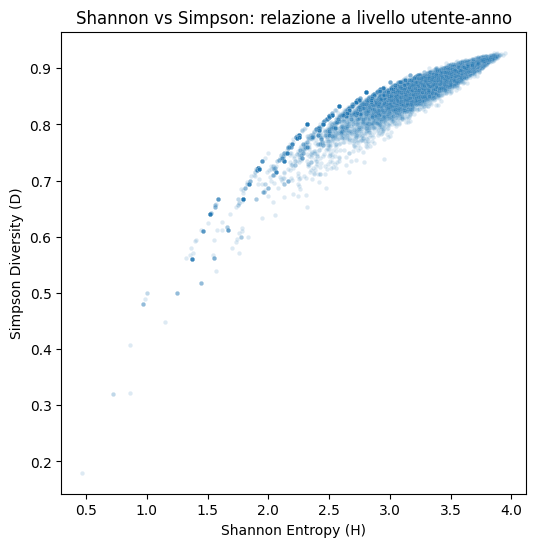

In [52]:
corr_hs = genre_df[["entropy", "simpson"]].corr().iloc[0, 1]
print(f"Correlazione tra Shannon Entropy e Simpson Diversity: {corr_hs:.3f}")

plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=genre_df.sample(min(20000, len(genre_df)), random_state=42),
    x="entropy", y="simpson", alpha=0.15, s=10
)
plt.xlabel("Shannon Entropy (H)")
plt.ylabel("Simpson Diversity (D)")
plt.title("Shannon vs Simpson: relazione a livello utente-anno")
plt.show()

In [53]:
# stessa regressione FE della cella "REGRESSIONE EFFETTI FISSI: ENTROPIA (H)" ma con Simpson come outcome
cols_simpson = ["simpson", "active_year", "log_ratings"]
for col in cols_simpson:
    genre_df[f"{col}_dm"] = genre_df[col] - genre_df.groupby("userId")[col].transform("mean")

model_simpson = smf.ols(
    "simpson_dm ~ active_year_dm + log_ratings_dm + C(year)",
    data=genre_df
).fit(cov_type="cluster", cov_kwds={"groups": genre_df["userId"]})

print("REGRESSIONE EFFETTI FISSI: SIMPSON DIVERSITY (D)")
print(model_simpson.summary().tables[1])

print()
print(f"Coefficiente active_year — Shannon (H): {model_entropy.params['active_year_dm']:.4f} "
      f"(p={model_entropy.pvalues['active_year_dm']:.4g})")
print(f"Coefficiente active_year — Simpson (D): {model_simpson.params['active_year_dm']:.4f} "
      f"(p={model_simpson.pvalues['active_year_dm']:.4g})")

REGRESSIONE EFFETTI FISSI: SIMPSON DIVERSITY (D)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0448      0.000   -197.222      0.000      -0.045      -0.044
C(year)[T.1996]     0.0485      0.001     86.320      0.000       0.047       0.050
C(year)[T.1997]     0.0424      0.001     84.263      0.000       0.041       0.043
C(year)[T.1998]     0.0445      0.001     40.487      0.000       0.042       0.047
C(year)[T.1999]     0.0473      0.001     82.923      0.000       0.046       0.048
C(year)[T.2000]     0.0414      0.000     86.725      0.000       0.040       0.042
C(year)[T.2001]     0.0406      0.000     85.301      0.000       0.040       0.042
C(year)[T.2002]     0.0465      0.000    103.593      0.000       0.046       0.047
C(year)[T.2003]     0.0427      0.000     94.366      0.000       0.042       0.044
C(year)[T.2004]     0.0449 

**Risultato** 
- 'Shannon e Simpson sono fortemente correlati a livello utente-anno (r = 0.943) e il segno del
coefficiente su `active_year` è concorde tra le due metriche: positivo e altamente significativo sia per H
(0.0063, p<0.001) sia per D (0.0006, p<0.001)
- L'ordine di grandezza assoluto non è direttamente confrontabile, perché le due scale sono diverse (H arriva fino a ~4 con 19 generi equidistribuiti, D è per costruzione compreso tra 0 e 1); normalizzando sul rispettivo range, gli effetti relativi risultano comunque dello stesso ordine

Il risultato principale è che la diversità dei generi aumenta con l'anzianità sulla piattaforma → può quindi essere
considerato **robusto alla scelta tra Shannon e Simpson**.

## Rilevazione di change-point nella traiettoria temporale della diversità

Applico l'algoritmo PELT (libreria `ruptures`) alla serie temporale dell'entropia media annua
(aggregata su tutti gli utenti del campione, per anno di calendario) per individuare eventuali punti di rottura
strutturale nella traiettoria della diversità, distinti dall'andamento lineare stimato nella regressione a effetti
fissi.

In [54]:
import ruptures as rpt

entropy_by_year = (
    genre_df.groupby("year")["entropy"]
    .mean()
    .sort_index()
)

signal = entropy_by_year.values
years = entropy_by_year.index.values

# testo più valori di penalizzazione:
# pen bassa = più sensibile (rischio di scambiare rumore per break-point),
# pen alta = più conservativa
changepoint_results = {}
for pen in [1, 3, 10]:
    algo = rpt.Pelt(model="rbf").fit(signal)
    bkps = algo.predict(pen=pen)
    # rpt restituisce SEMPRE come ultimo indice la lunghezza della serie (fine
    # dell'ultimo segmento, non un vero break-point): lo escludo prima di
    # mappare gli indici interni agli anni
    internal_bkps = bkps[:-1]
    changepoint_results[pen] = [int(years[i - 1]) for i in internal_bkps]

for pen, years_found in changepoint_results.items():
    label = years_found if years_found else "nessun break-point interno rilevato"
    print(f"pen={pen}: {label}")

breakpoint_years = changepoint_results[3]

pen=1: [1999]
pen=3: nessun break-point interno rilevato
pen=10: nessun break-point interno rilevato


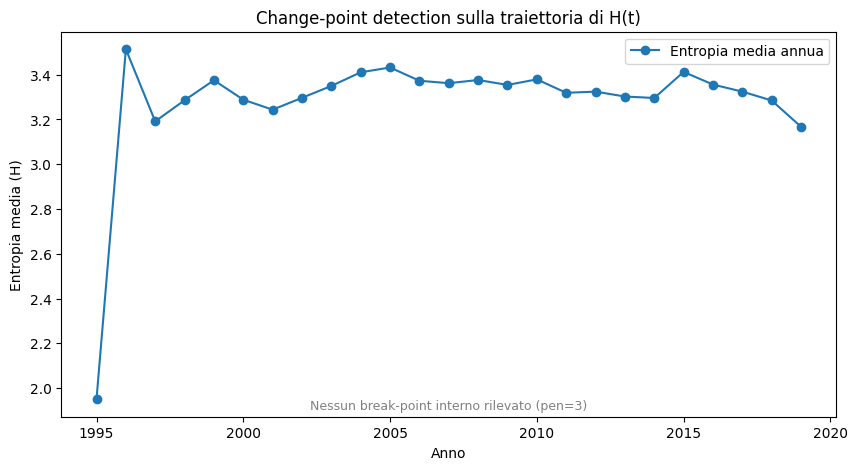

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(years, signal, marker="o", label="Entropia media annua")

if breakpoint_years:
    for by in breakpoint_years:
        plt.axvline(by, color="red", linestyle="--", alpha=0.6, label=f"change-point {by}")
else:
    plt.annotate("Nessun break-point interno rilevato (pen=3)",
                 xy=(0.5, 0.02), xycoords="axes fraction", ha="center", fontsize=9, color="gray")

plt.xlabel("Anno")
plt.ylabel("Entropia media (H)")
plt.title("Change-point detection sulla traiettoria di H(t)")
plt.legend()
plt.show()

**Risultato.** Solo con la penalizzazione più bassa (pen=1, la più sensibile al rumore) emerge un possibile break-point nel **1999**, mentre con penalizzazioni più conservative (pen=3 e pen=10) non emerge nulla. 
Il break del 1999 è verosimilmente legato alla scarsità di osservazioni nei primissimi anni del campione (pochi utenti, anni di partenza di MovieLens) piuttosto che a una vera rottura strutturale nel comportamento di consumo. 
In ogni caso, **nessuna rottura robusta** emerge a livelli di penalizzazione conservativi, e l'aumento di entropia osservato nella regressione a effetti fissi è meglio descritto come un **trend graduale** piuttosto che come uno o più salti bruschi legati a eventi specifici, fatta salva la cautela dovuta al break-point trovato con pen=1.

## Sintesi della verifica di robustezza

In [56]:
robustness_summary = pd.DataFrame([
    {
        "risultato": "H (Shannon) aumenta con active_year",
        "metrica_alternativa": "Simpson Diversity (D)",
        "coef_principale": model_entropy.params["active_year_dm"],
        "coef_alternativo": model_simpson.params["active_year_dm"],
        "robusto": "SI — stesso segno (positivo), entrambi altamente significativi, r=0.94 tra le due metriche"
    },
    {
        "risultato": "Novelty (19 generi) diminuisce con active_year",
        "metrica_alternativa": "Novelty (Genome Tags, soglia 0.5)",
        "coef_principale": coef_novelty_genre,
        "coef_alternativo": coef_novelty_genome,
        "robusto": "SI nella direzione del segno — ma l'effetto soffitto PEGGIORA (quasi doppio), non migliora"
    },
    {
        "risultato": "Novelty (Genome Tags, soglia 0.5)",
        "metrica_alternativa": "Novelty (Genome Tags, soglia 0.7)",
        "coef_principale": coef_novelty_genome,
        "coef_alternativo": sensitivity_table.loc[2, "coef_active_year"],
        "robusto": "SI — l'effetto si rafforza ulteriormente con vocabolario piu' selettivo"
    },
    {
        "risultato": "Novelty (Genome Tags, soglia 0.5)",
        "metrica_alternativa": "Novelty (Genome Tags, top-10 per film)",
        "coef_principale": coef_novelty_genome,
        "coef_alternativo": sensitivity_table.loc[3, "coef_active_year"],
        "robusto": "SI — coefficiente ancora piu' marcato (-0.014)"
    },
    {
        "risultato": "Traiettoria di H(t) mostra rotture strutturali",
        "metrica_alternativa": "Change-point detection (PELT, pen=1/3/10)",
        "coef_principale": float("nan"),
        "coef_alternativo": float("nan"),
        "robusto": "NO break-point interno rilevato a nessun livello di penalizzazione: trend graduale, non a scalini"
    },
])
robustness_summary

,risultato,metrica_alternativa,coef_principale,coef_alternativo,robusto
0,H (Shannon) aumenta con active_year,Simpson Diversity (D),0.006341,0.000592,"SI — stesso segno (positivo), entrambi altamen..."
1,Novelty (19 generi) diminuisce con active_year,"Novelty (Genome Tags, soglia 0.5)",-0.002205,-0.004551,SI nella direzione del segno — ma l'effetto so...
2,"Novelty (Genome Tags, soglia 0.5)","Novelty (Genome Tags, soglia 0.7)",-0.004551,-0.007139,SI — l'effetto si rafforza ulteriormente con v...
3,"Novelty (Genome Tags, soglia 0.5)","Novelty (Genome Tags, top-10 per film)",-0.004551,-0.014164,SI — coefficiente ancora piu' marcato (-0.014)
4,Traiettoria di H(t) mostra rotture strutturali,"Change-point detection (PELT, pen=1/3/10)",NaN,NaN,NO break-point interno rilevato a nessun livel...


## Conclusioni del notebook 04_robustness

**1) Diversità dei generi (H) — risultato robusto.** L'aumento dell'entropia con l'anzianità sulla piattaforma
(già osservato in `02_EDA`, coef. 0.0063) è confermato dall'indice di Simpson (coef. 0.0006), con lo stesso
segno, entrambi altamente significativi, e una correlazione di 0.943 tra le due metriche a livello utente-anno.
Il risultato non dipende dalla scelta specifica tra Shannon e Simpson.

**2) Novelty granulare sui Genome Tags — risultato contro-intuitivo, confermato e rafforzato dalla sensitivity.**
L'ipotesi che una tassonomia più granulare (Genome Tags) avrebbe rivelato una riduzione "vera" dell'esplorazione,
mascherata dall'effetto soffitto dei 19 macro-generi, **non è confermata dai dati, anzi è contraddetta**. Il
coefficiente di declino della novelty è quasi doppio sui Genome Tags (-0.0046) rispetto ai generi (-0.0022), e
la sensitivity analysis mostra che l'effetto **si rafforza ulteriormente** restringendo il vocabolario a soglie
più selettive: -0.0071 a soglia 0.7, -0.0142 con i soli top-10 tag per film. <br> La spiegazione è meccanica: con ~44
tag medi per film a soglia 0.5, un utente medio copre il 61.2% del vocabolario di 1128 tag disponibili già in
un singolo anno di consumo normale, per cui la saturazione avviene ancora più rapidamente che con soli 19
generi. <br>
Questo va riportato come conclusione esplicita: la granularità della tassonomia non è la causa
dell'effetto soffitto osservato con i generi anzi, tassonomie più fini e selettive lo rendono più marcato, e
il pattern di rapida esplorazione seguita da saturazione appare un tratto strutturale del comportamento di
consumo in questo dataset, non un artefatto della metrica scelta.

**3) Limite di copertura e bias verso i consumi mainstream — confermato con numeri precisi.** Solo il 23.4% dei
film del dataset (13.816 su 59.047) possiede Genome Tags, ma questi coprono ben il 98.7% dei rating osservati
(24.674.113 su 25.000.095): un divario enorme tra copertura a livello di film e a livello di rating, che
conferma in modo netto che i film con Genome Tags sono sistematicamente i più popolari/valutati. Ogni
conclusione basata sui Genome Tags si applica quindi a un sotto-campione fortemente mainstream del catalogo ed
esclude sistematicamente i film di nicchia (limite da esplicitare quando si presenta questa metrica).

**4) Change-point — nessuna rottura robusta, un break-point solo con pen=1.** L'algoritmo PELT non individua
break-point interni con penalizzazioni conservative (pen=3 e pen=10). Con la penalizzazione più bassa (pen=1)
emerge invece un possibile break nel 1999, verosimilmente legato alla scarsità di osservazioni nei primissimi
anni del campione piuttosto che a una vera rottura nel comportamento di consumo. L'aumento di entropia osservato
è quindi meglio descritto come un trend graduale nel tempo piuttosto che come una rottura netta legata a un
evento specifico (una conclusione che regge, ma va riportata con questa cautela sul risultato a pen=1).

**Sintesi robusti vs fragili.**
- **Robusti:** aumento della diversità dei generi con l'anzianità (Shannon/Simpson), peggioramento (non miglioramento) dell'effetto soffitto con 
  la novelty granulare, confermato e rafforzato dalla sensitivity, assenza di rotture strutturali a penalizzazioni conservative (pen=3/10) nella traiettoria di H(t).
- **Fragile / da trattare con cautela:** qualunque conclusione basata sui soli Genome Tags, per via del forte
  bias di copertura verso i film mainstream (punto 3), il break-point del 1999 trovato solo con pen=1, da non riportare come
  evidenza sostanziale ma da segnalare come possibile artefatto legato alla scarsità di dati nei primi anni.